In [3]:
import os
import json
import numpy as np
import xarray as xr
import proplot as pplt
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})

In [4]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
PREDSDIR  = CONFIGS['filepaths']['predictions']
MODELS    = CONFIGS['experiments']
SPLIT     = 'valid'
STYLE     = {
    'pod':('gray6','POD'),
    'baseline':('blue6','Baseline NN'),
    'nonparametric':('yellow3','Nonparametric Kernel NN'),
    'parametric':('red6','Parametric Kernel NN')}

In [11]:
def get_r2(ytrue,ypred):
    ssres = ((ytrue-ypred)**2).sum(skipna=True)
    sstot = ((ytrue-ytrue.mean(skipna=True))**2).sum(skipna=True)
    return float(1-ssres/sstot)

def get_nn_nparams(kind,nfieldvars,nlevs,nlocalvars):
    def nparams(nfeatures):
        return (nfeatures*256)+256+(256*128)+128+(128*64)+64+(64*32)+32+(32*1)+1
    if kind=='baseline':
        return nparams(nfieldvars*nlevs+nlocalvars)
    elif kind=='nonparametric':
        kernel = nfieldvars*nlevs
        return kernel+nparams(nfieldvars+nlocalvars)
    elif kind=='parametric':
        kernel = 2*nfieldvars
        return kernel+nparams(nfieldvars+nlocalvars)

def get_nsigs(fieldvars,splitsdir):
    with xr.open_dataset(os.path.join(splitsdir,'norm_train.h5'),engine='h5netcdf') as ds:
        return ds.sizes['sig'] if 'sig' in ds[fieldvars[0]].dims else 1

def pareto_front(records):
    ordered = sorted(records,key=lambda r:r['nparams'])
    front   = []
    bestr2  = -np.inf
    for r in ordered:
        if r['r2']>bestr2:
            front.append(r)
            bestr2 = r['r2']
    return front

In [12]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

nsigs = get_nsigs(next(iter(MODELS['nn']['runs'].values()))['fieldvars'], SPLITSDIR)

results = []
for group in ['pod','nn']:
    for name,config in MODELS[group]['runs'].items():
        filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
        if os.path.exists(filepath):
            with xr.open_dataset(filepath) as ds:
                predtp  = ds.tp.load()
        ytrue,ypred = xr.align(truetp,predtp,join='inner')
        if 'seed' in ypred.dims:
            ypred = ypred.mean('seed')
        if group=='pod':
            with np.load(os.path.join(MODELSDIR,'pod',f'{name}.npz')) as d:
                nparams = int(d['nparams'])
            kind = 'pod'
        else:
            kind = config['kind']
            metapath = os.path.join(MODELSDIR,'nn',f'{name}_meta.json')
            if os.path.exists(metapath):
                with open(metapath) as _f:
                    nparams = json.load(_f)['nparams']
            else:
                fieldvars,localvars = config['fieldvars'],config.get('localvars',[])
                nparams = get_nn_nparams(kind,len(fieldvars),nsigs,len(localvars))
        color,label = STYLE.get(kind,('gray6',kind))
        results.append((name,get_r2(ytrue, ypred),nparams,color,label))

print(f'Found {len(results)} models with predictions!')

Found 10 models with predictions!


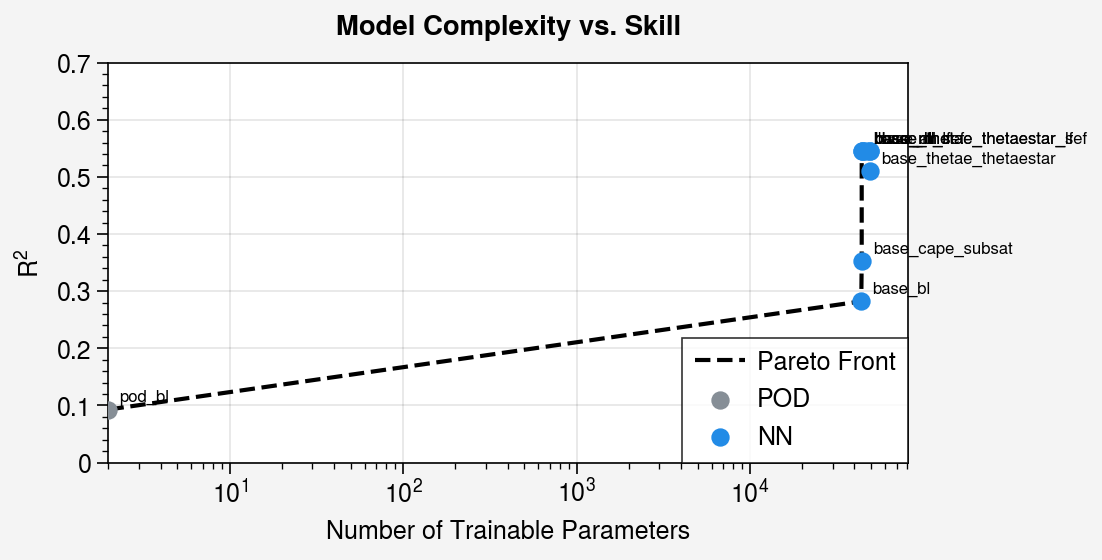

In [13]:
fig,ax = pplt.subplots(refwidth=4,refheight=2)
ax.format(suptitle='Model Complexity vs. Skill',grid=True,
    xlabel='Number of Trainable Parameters',xscale='log',xformatter='log',
    ylabel='R$^2$',ylim=(0,0.7))

pod  = [(n,r,p,c,l) for n,r,p,c,l in results if l=='POD']
nn   = [(n,r,p,c,l) for n,r,p,c,l in results if l!='POD']

for group,label in [(pod,'POD'),(nn,'NN')]:
    ax.scatter([p for _,r,p,_,_ in group],[r for _,r,p,_,_ in group],
               label=label,color=group[0][3] if group else None,zorder=3)
for n,r,p,_,_ in results:
    ax.annotate(n,(p,r),xytext=(4,3),textcoords='offset points',fontsize=6)
front = pareto_front([dict(name=n,r2=r,nparams=p) for n,r,p,_,_ in results])
if len(front)>1:
    ax.plot([r['nparams'] for r in front],[r['r2'] for r in front],'k--',label='Pareto Front')
ax.legend(loc='lr',ncols=1)
pplt.show()